In [4]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import StateGraph,START,END

from langgraph.graph.message import add_messages

In [5]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [6]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [7]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [8]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
def superbot(state:State):
    return{
        "messages":[llm.invoke(state['messages'])]
    }
    

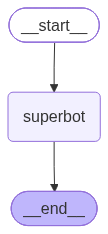

In [12]:
graph = StateGraph(State)
graph.add_node("superbot",superbot)

graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder = graph.compile(checkpointer=memory)
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [13]:
from langchain.messages import HumanMessage
config = {"configurable":{"thread_id":"1"}}
result = graph_builder.stream(
    {
        "messages": [
            HumanMessage(
                content="My name is Rajat."
            )
        ]
    },
    config=config,
    stream_mode="updates"
)


for update in result:
    print(update)

{'superbot': {'messages': [AIMessage(content="Nice to meet you, Rajat! If there's anything you'd like to talk about or any question you have, just let me know.", additional_kwargs={'reasoning_content': 'The user says "My name is Rajat." Probably they want to respond. Maybe just acknowledge. There\'s no request. We can respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 77, 'total_tokens': 143, 'completion_time': 0.137124685, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.003061741, 'prompt_tokens_details': None, 'queue_time': 0.402650276, 'total_time': 0.140186426}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a089d4-b8f5-7232-913c-3d71565353da-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 66, 'total_tokens': 143, 'output_toke

In [14]:
result = graph_builder.stream(
    {
        "messages": [
            HumanMessage(
                content="I love  to play Football"
            )
        ]
    },
    config=config,
    stream_mode="updates"
)


for update in result:
    print(update)

{'superbot': {'messages': [AIMessage(content='That’s awesome, Rajat! ⚽️  \n\nDo you have a favorite position on the field?  \n- Are you more of a striker who loves to finish chances?  \n- A play‑making midfielder who controls the tempo?  \n- A solid defender keeping the opposition at bay?  \n- Or maybe you enjoy the energy of a full‑back or goalkeeper?\n\nAlso, do you follow any professional leagues or teams? I’d love to hear about the matches that get you pumped and any memorable moments you’ve had on the pitch!', additional_kwargs={'reasoning_content': 'User says they love to play football. We can respond engagingly, ask about their experience, position, favorite team, etc. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 147, 'prompt_tokens': 120, 'total_tokens': 267, 'completion_time': 0.316144688, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.028596533, 'prompt_tokens_details': None, 'queue_time': 0.330069095, 'total_time': 0.3447

In [15]:
result = graph_builder.stream(
    {
        "messages": [
            HumanMessage(content="My name is Rajat.")
        ]
    },
    config=config,
    stream_mode="values"
)

for value in result:
    print(value)

{'messages': [HumanMessage(content='My name is Rajat.', additional_kwargs={}, response_metadata={}, id='905b2a4e-6ea8-4239-807b-4e26ab0116c2'), AIMessage(content="Nice to meet you, Rajat! If there's anything you'd like to talk about or any question you have, just let me know.", additional_kwargs={'reasoning_content': 'The user says "My name is Rajat." Probably they want to respond. Maybe just acknowledge. There\'s no request. We can respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 77, 'total_tokens': 143, 'completion_time': 0.137124685, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.003061741, 'prompt_tokens_details': None, 'queue_time': 0.402650276, 'total_time': 0.140186426}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a089d4-b8f5-7232-913c-3d71565353da-0', tool_calls=